In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# Cherry Picking

In [3]:
import pandas as pd
import requests
import io

url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"

# ---- STEP 1: Download file as text ----
text = requests.get(url).text

# ---- STEP 2: Extract header lines starting with % ----
header_lines = [line for line in text.splitlines() if line.startswith("%")]

# ---- STEP 3: Extract ONLY numeric rows ----
numeric_lines = [
    line for line in text.splitlines()
    if not line.startswith("%") and not line.startswith("#") and line.strip() != ""
]

# ---- STEP 4: Parse numeric rows into a clean DataFrame ----
df_data = pd.read_csv(
    io.StringIO("\n".join(numeric_lines)),
    sep=r"\s+",
    engine="python",
    header=None
)

df_data.columns = [
    "Year", "month", "month_Anomaly", "Monthly_Unc",
    "Annual_Anomaly", "Annual_Unc",
    "5_Anomaly", "5__Unc",
    "10_Anomaly", "10__Unc",
    "20_Anomaly", "20__Unc"
]

df_data

,Year,month,month_Anomaly,Monthly_Unc,Annual_Anomaly,Annual_Unc,5_Anomaly,5__Unc,10_Anomaly,10__Unc,20_Anomaly,20__Unc
0,1850,1,-0.753,0.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.202,0.416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.367,0.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.596,0.324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.619,0.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,2024,8,1.257,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,2024,9,1.138,0.036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,2024,10,1.182,0.042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,2024,11,1.169,0.057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_data["Date"] = pd.to_datetime(df_data[["Year", "month"]].assign(DAY=1))
df_data

,Year,month,month_Anomaly,Monthly_Unc,Annual_Anomaly,Annual_Unc,5_Anomaly,5__Unc,10_Anomaly,10__Unc,20_Anomaly,20__Unc,Date
0,1850,1,-0.753,0.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-01-01
1,1850,2,-0.202,0.416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-02-01
2,1850,3,-0.367,0.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-03-01
3,1850,4,-0.596,0.324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-04-01
4,1850,5,-0.619,0.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,2024,8,1.257,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-01
4196,2024,9,1.138,0.036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01
4197,2024,10,1.182,0.042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-01
4198,2024,11,1.169,0.057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-01


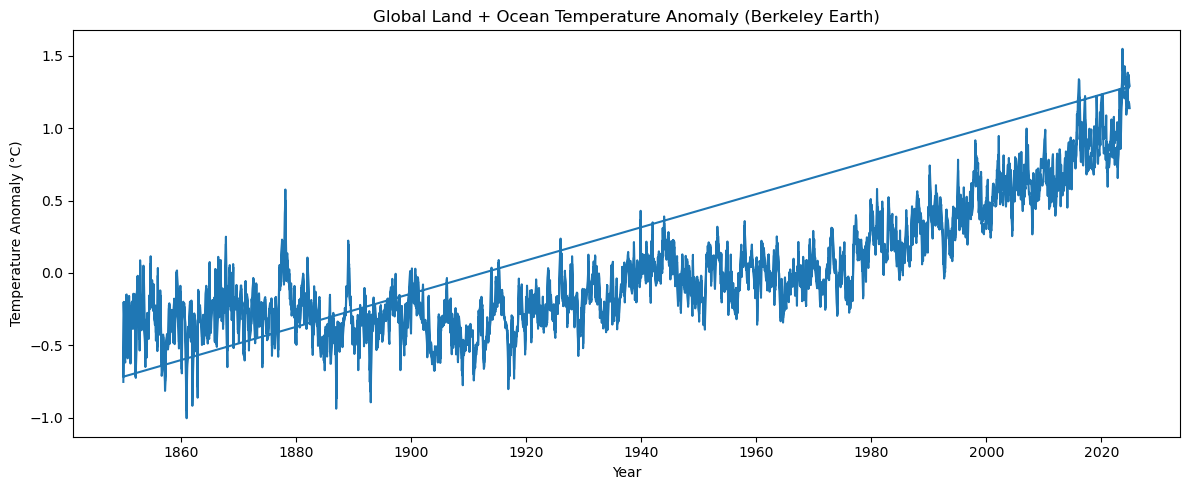

In [8]:
# ---- 4. Plot monthly global anomaly ----
plt.figure(figsize=(12, 5))
plt.plot(df_data["Date"], df_data["month_Anomaly"])
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Land + Ocean Temperature Anomaly (Berkeley Earth)")
plt.tight_layout()
plt.show()

# Spurious correlations

Number of websites on the internet vs Total wind power generated globally  
ref: https://tylervigen.com/spurious/correlation/5236_number-of-websites-on-the-internet_correlates-with_total-wind-power-generated-globally#datadetail

In [2]:
# ---- Data ----
years = list(range(1991, 2019))

websites = [
    1, 10, 130, 2738, 23500, 257601, 1117260, 2410070, 3177450, 17087200,
    29254400, 38760400, 40912300, 51611600, 64780600, 85507300, 121893000,
    172339000, 238028000, 206957000, 346004000, 697089000, 672985000,
    968882000, 863106000, 1045530000, 1766930000, 1630320000
]

wind_power = [
    4.09695, 4.61206, 5.55793, 7.28441, 7.93552, 9.28889, 12.134, 16.1075,
    21.2765, 31.3317, 38.3652, 52.7331, 64.5029, 84.6314, 104.241, 133.42,
    171.303, 221.363, 277.775, 339.401, 435.106, 521.503, 645.078, 717.25,
    827.435, 957.251, 1127.11, 1263.52
]


In [3]:
# ---- Function ----
def calculate_correlation(array1, array2):
    correlation, p_value = stats.pearsonr(array1, array2)
    r_squared = correlation**2
    return correlation, r_squared, p_value

# ---- Convert lists to numpy arrays ----
array_1 = np.array(websites)
array_2 = np.array(wind_power)

# ---- Names for display ----
array_1_name = "Number of websites on the internet"
array_2_name = "Total wind power generated globally"

# ---- Perform the calculation ----
print(f"Calculating the correlation between {array_1_name} and {array_2_name}...")
correlation, r_squared, p_value = calculate_correlation(array_1, array_2)

# ---- Print results ----
print("Correlation Coefficient:", correlation)
print("R-squared:", r_squared)
print("P-value:", p_value)


Calculating the correlation between Number of websites on the internet and Total wind power generated globally...
Correlation Coefficient: 0.9784944131600884
R-squared: 0.9574513165855059
P-value: 2.3689343033351033e-19


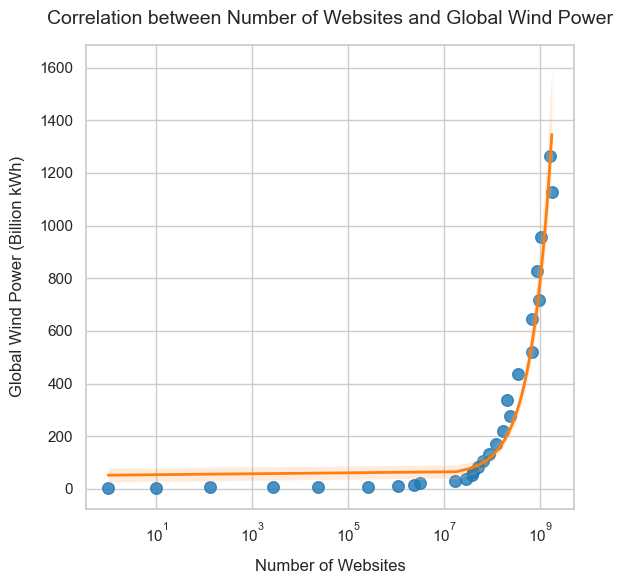

In [7]:
# Convert to DataFrame for Seaborn
data = pd.DataFrame({
    "Websites": websites,
    "Wind Power (Billion kWh)": wind_power
})

# ---- Set style ----
sns.set_theme(style="whitegrid")  # modern clean grid
plt.figure(figsize=(6, 6))

# ---- Scatter + regression ----
sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    scatter_kws={"color": "#1f77b4", "s": 70},  # blue points
    line_kws={"color": "#ff7f0e", "linewidth": 2},  # orange line
    ci=95
)

# ---- Labels & title ----
plt.xlabel("Number of Websites", fontsize=12, labelpad=10)
plt.ylabel("Global Wind Power (Billion kWh)", fontsize=12, labelpad=10)
plt.title("Correlation between Number of Websites and Global Wind Power", fontsize=14, pad=15)
plt.title("Correlation between Number of Websites and Global Wind Power", fontsize=14, pad=15)
# 
# Optional: log scale for websites
plt.xscale("log")

plt.savefig("/Users/wenlanzhang/PycharmProjects/Mapineq/src/case_study/Data_quality/Figrue/Spurious_correlations.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

# False Causality